# Dust Emission Models: Overview

tengri ships **11 dust emission models** spanning analytic blackbodies
through full radiative-transfer template grids.  All are pure-JAX
(JIT-compatible, fully differentiable) and enforce energy balance: the
total IR luminosity matches the total absorbed UV/optical luminosity
upstream.

| Model | Type | Free parameters | Source |
|---|---|---|---|
| `modified_blackbody` | analytic | `dust_T`, `dust_beta_ir` | — |
| `casey2012` | analytic | `dust_T`, `dust_beta_ir`, `dust_alpha_mir` | Casey 2012 |
| `pah_drude` | analytic | (template) | Smith+ 2007 Drude profiles |
| `schreiber2016` | analytic | `dust_T` | Schreiber+ 2016 |
| `dale2014` | template | `dust_alpha_dale` | Dale+ 2014 |
| `draine_li2007` | template grid | `dust_qpah`, `dust_umin`, `dust_gamma_dl` | Draine & Li 2007 |
| `draine_li2014` | template grid | + `dust_alpha_dl14` | Draine & Li 2014 |
| `astrodust` | template grid | `dust_lgU` | Hensley & Draine 2023 |
| `bosa` | template grid | `dust_log_ssfr` | Boquien & Salim 2021 |
| `themis` | template grid | `dust_qhac`, `dust_umin` | Jones+ 2017 |
| `draine2021_pah` (PAHspec) | template grid | `dust_lgU` + categorical knobs | Draine, Li, Hensley+ 2021 |

The `astrodust`, `bosa`, `themis`, and `draine2021_pah` models load real
data from canonical published sources at runtime; build them with the
`scripts/build_*_hdf5.py` scripts.  The other template grids ship with
the repo (`data/dl07_templates_v2.h5`, `data/dl14_templates.h5`,
`data/dale2014_templates.h5`).

In [1]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore")

from tengri.components.dust.emission import DUST_EMISSION_MODELS

# Wavelength grid: 1 to 1000 um in Angstrom.
wave_aa = jnp.logspace(np.log10(1.0e4), np.log10(1.0e7), 1000)
wave_um = np.asarray(wave_aa) * 1.0e-4
L_ABS = 1.0e44  # erg/s, absorbed UV/optical luminosity to re-emit

W0509 01:54:56.516443 1200105 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
W0509 01:54:56.547854 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:56.550347 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:56.557381 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:56.560209 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:56.697918 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:56.701802 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:56.704394 1199996 pjrt_executable.cc

W0509 01:54:57.416496 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:57.419367 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:57.446033 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:57.458797 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:57.466001 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:57.469316 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:57.476457 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:57.478983 1199996 pjrt_executable.cc:638] Assume v

## 1. All Models — Common Energy Balance

All eleven emission models accept an absorbed luminosity `L_absorbed`
and return `L_nu` in the matching per-Hz unit.  The frequency integral
of the returned spectrum equals the input absorbed luminosity.

W0509 01:54:57.605038 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:57.607524 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0509 01:54:57.768735 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:57.772251 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0509 01:54:58.149067 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:58.162368 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:58.175413 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:58.177850 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0509 01:54:58.663859 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0509 01:54:58.666700 1199996 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


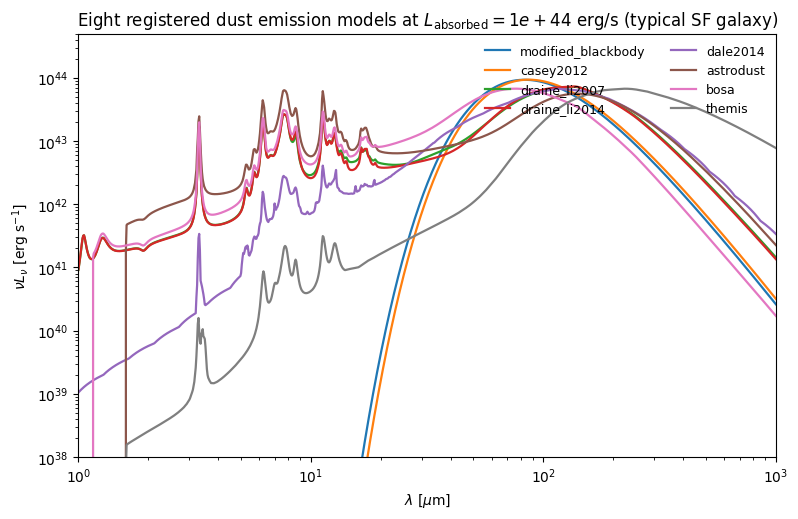

In [2]:
def _safe_eval(name, **kw):
    try:
        return np.asarray(DUST_EMISSION_MODELS[name](wave_aa, L_absorbed=L_ABS, **kw))
    except Exception as e:
        print(f"[skip] {name}: {e!s}")
        return None


seds = {}
seds["modified_blackbody"] = _safe_eval(
    "modified_blackbody", dust_T=30.0, dust_beta_ir=1.8,
)
seds["casey2012"] = _safe_eval(
    "casey2012", dust_T=30.0, dust_beta_ir=1.8, dust_alpha_mir=2.0,
)
seds["draine_li2007"] = _safe_eval(
    "draine_li2007", dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=2.5,
)
seds["draine_li2014"] = _safe_eval(
    "draine_li2014",
    dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=2.5, dust_alpha_dl14=2.0,
)
seds["dale2014"] = _safe_eval("dale2014", dust_alpha_dale=2.0)
seds["astrodust"] = _safe_eval(
    "astrodust", dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=2.5,
)
seds["bosa"] = _safe_eval("bosa", dust_log_ssfr=-9.6)
seds["themis"] = _safe_eval(
    "themis", dust_umin=1.0, dust_gamma_dl=0.01, dust_qhac=0.17,
)

c_aa_per_s = 2.99792458e18
nu = c_aa_per_s / np.asarray(wave_aa)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$ [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$ [erg s$^{-1}$]")
ax.set_xlim(1, 1e3)

cmap = plt.get_cmap("tab10")
for k, (name, sed) in enumerate(seds.items()):
    if sed is None:
        continue
    ax.plot(wave_um, nu * sed, color=cmap(k % 10), lw=1.6, label=name)

ax.set_ylim(1e38, 5e44)
ax.legend(loc="upper right", frameon=False, fontsize=9, ncol=2)
ax.set_title(
    rf"Eight registered dust emission models at $L_{{\rm absorbed}}={L_ABS:.0e}$ erg/s "
    r"(typical SF galaxy)"
)
plt.show()

## 2. Modified Blackbody and Casey+2012 — Analytic Templates

The simplest models: optically-thin modified blackbody (2 params) and
the Casey 2012 mid-IR power-law join (3 params).  Both are pure
analytic and don't require any data files.

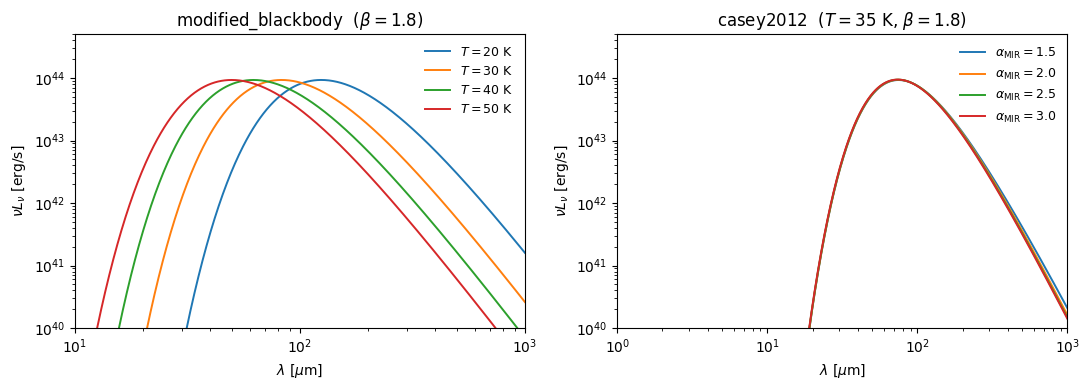

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# -- Modified blackbody temperature sweep --
ax = axes[0]
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$ [$\mu$m]"); ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_xlim(10, 1e3); ax.set_ylim(1e40, 5e44)
for T in (20, 30, 40, 50):
    L_nu = DUST_EMISSION_MODELS["modified_blackbody"](
        wave_aa, L_absorbed=L_ABS, dust_T=T, dust_beta_ir=1.8,
    )
    ax.plot(wave_um, nu * np.asarray(L_nu), lw=1.4, label=fr"$T={T}$ K")
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.set_title(r"modified_blackbody  ($\beta=1.8$)")

# -- Casey+2012 alpha_mir sweep --
ax = axes[1]
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$ [$\mu$m]"); ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_xlim(1, 1e3); ax.set_ylim(1e40, 5e44)
for alpha in (1.5, 2.0, 2.5, 3.0):
    L_nu = DUST_EMISSION_MODELS["casey2012"](
        wave_aa, L_absorbed=L_ABS, dust_T=35.0, dust_beta_ir=1.8,
        dust_alpha_mir=alpha,
    )
    ax.plot(wave_um, nu * np.asarray(L_nu), lw=1.4,
            label=fr"$\alpha_{{\rm MIR}}={alpha}$")
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.set_title(r"casey2012  ($T=35$ K, $\beta=1.8$)")

fig.tight_layout()
plt.show()

## 3. Draine & Li 2007 / 2014 — Real Template Grids

DL07 (Draine & Li 2007, ApJ 657 810) and DL14 (Draine et al. 2014,
ApJ 780 172) are the workhorse template grids in the SED-fitting
community.  DL07 has 3 free parameters; DL14 adds a power-law slope
`alpha_dl14` for a 4-D grid (q_PAH × U_min × gamma × alpha).

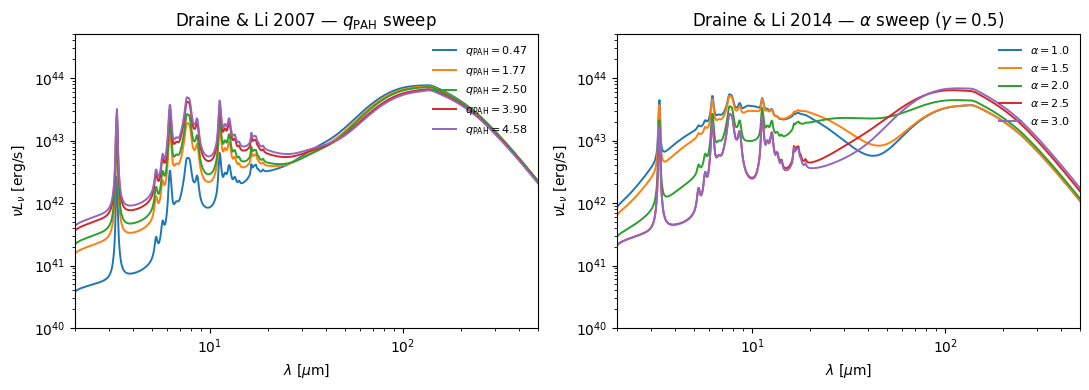

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# DL07 q_PAH sweep
ax = axes[0]
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$ [$\mu$m]"); ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_xlim(2, 5e2); ax.set_ylim(1e40, 5e44)
for qpah in (0.47, 1.77, 2.50, 3.90, 4.58):
    L_nu = DUST_EMISSION_MODELS["draine_li2007"](
        wave_aa, L_absorbed=L_ABS, dust_umin=1.0,
        dust_gamma_dl=0.01, dust_qpah=qpah,
    )
    ax.plot(wave_um, nu * np.asarray(L_nu), lw=1.4,
            label=fr"$q_{{\rm PAH}}={qpah:.2f}$")
ax.legend(loc="upper right", frameon=False, fontsize=8)
ax.set_title(r"Draine & Li 2007 — $q_{\rm PAH}$ sweep")

# DL14 alpha_dl14 sweep
ax = axes[1]
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$ [$\mu$m]"); ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_xlim(2, 5e2); ax.set_ylim(1e40, 5e44)
for alpha in (1.0, 1.5, 2.0, 2.5, 3.0):
    L_nu = DUST_EMISSION_MODELS["draine_li2014"](
        wave_aa, L_absorbed=L_ABS, dust_umin=1.0, dust_gamma_dl=0.5,
        dust_qpah=2.5, dust_alpha_dl14=alpha,
    )
    ax.plot(wave_um, nu * np.asarray(L_nu), lw=1.4,
            label=fr"$\alpha={alpha:.1f}$")
ax.legend(loc="upper right", frameon=False, fontsize=8)
ax.set_title(r"Draine & Li 2014 — $\alpha$ sweep ($\gamma=0.5$)")

fig.tight_layout()
plt.show()

## 4. Astrodust+PAH (Hensley & Draine 2023) — Real Template Grid

Replaces the synthetic placeholder previously shipped with tengri.
The canonical FITS file (doi:10.7910/DVN/3B6E6S, "Astrodust+PAH Model
Output") contains a 91-point :math:`\log_{10} U` grid at the H&D 2022
fiducial size distribution / ionization fraction (single MW R_V=3.1
sightline configuration).

Build with::

    python scripts/build_astrodust_hdf5.py --output data/astrodust_templates.h5 --download

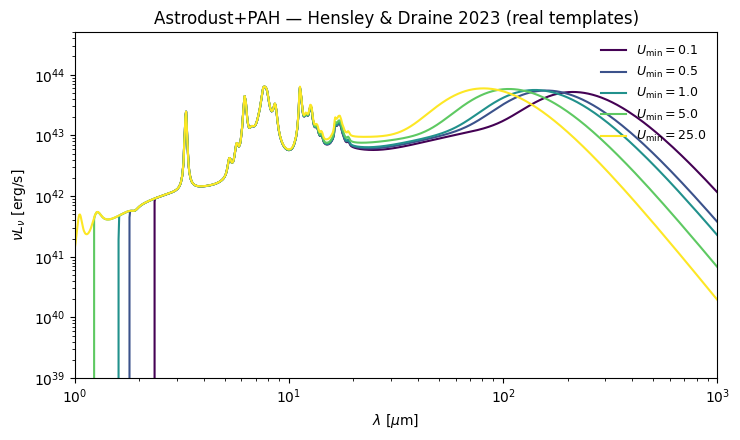

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$ [$\mu$m]"); ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_xlim(1, 1e3); ax.set_ylim(1e39, 5e44)

cmap = plt.get_cmap("viridis")
# Tengri's astrodust adapter accepts (qpah, umin, gamma) for back-compat;
# the real H&D 2023 grid only has lgU as a continuous axis, so a sweep
# over umin is the canonical demonstration.
for k, umin in enumerate([0.1, 0.5, 1.0, 5.0, 25.0]):
    L_nu = DUST_EMISSION_MODELS["astrodust"](
        wave_aa, L_absorbed=L_ABS, dust_umin=umin,
        dust_gamma_dl=0.01, dust_qpah=2.5,
    )
    ax.plot(wave_um, nu * np.asarray(L_nu), color=cmap(k / 4), lw=1.5,
            label=fr"$U_{{\rm min}}={umin}$")
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.set_title("Astrodust+PAH — Hensley & Draine 2023 (real templates)")

fig.tight_layout()
plt.show()

## 5. Draine+2021 PAHspec — Starlight-Spectrum-Aware

The Draine, Li, Hensley et al. 2021 PAHspec library (arXiv:2011.07046)
is a 4-axis grid that captures **starlight-spectrum dependence**: at
fixed ``q_PAH`` the fraction of IR power in PAH features can vary by
~2× between FUV-rich (3 Myr starburst) and FUV-poor (M31 bulge)
heating.

Exposed via the new SEDComponent dispatch, not via
``DUST_EMISSION_MODELS``::

    from tengri.components.dust.emission_component import (
        DustEmissionSEDComponent, DustEmissionSEDComponentConfig,
    )

    cfg = DustEmissionSEDComponentConfig(
        template="draine2021_pah",
        pahspec_starlight="auto",  # nearest-neighbour from upstream stellar params
        pahspec_auto_age_myr=10.0,
        pahspec_auto_log_z_solar=0.0,
        pahspec_auto_sps_family="BC03",
    )

Build the data with::

    python scripts/build_pahspec_hdf5.py --output data/pahspec_draine2021.h5 --download

See `examples/dust/plot_pahspec_lgU_sweep.py` and
`plot_pahspec_starlight_sweep.py` for parameter sweeps over the full
published range.

## 6. BOSA (Boquien & Salim 2021) — Real Template Grid

Replaces the synthetic placeholder with the canonical 41×14 grid
(``log L_TIR`` × ``log sSFR``) from doi at
``salims.pages.iu.edu/bosa``.

Build with::

    python scripts/build_bosa_hdf5.py --output data/bosa_templates.h5 --download

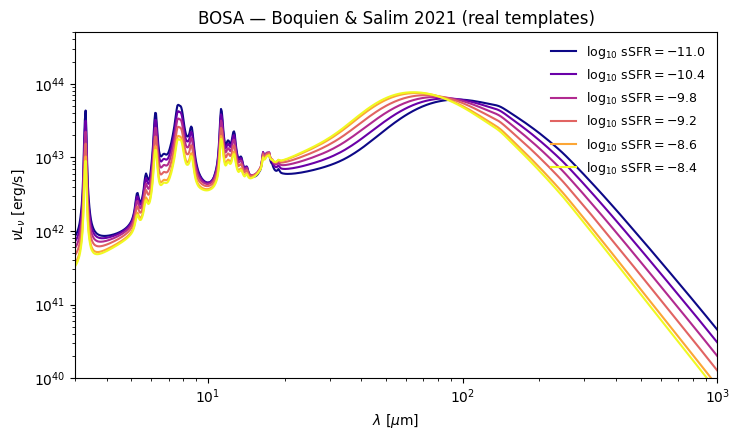

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$ [$\mu$m]"); ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_xlim(3, 1e3); ax.set_ylim(1e40, 5e44)

cmap = plt.get_cmap("plasma")
for k, lssfr in enumerate([-11.0, -10.4, -9.8, -9.2, -8.6, -8.4]):
    L_nu = DUST_EMISSION_MODELS["bosa"](
        wave_aa, L_absorbed=L_ABS, dust_log_ssfr=lssfr,
    )
    ax.plot(wave_um, nu * np.asarray(L_nu), color=cmap(k / 5), lw=1.5,
            label=fr"$\log_{{10}}\,\mathrm{{sSFR}}={lssfr:+.1f}$")
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.set_title("BOSA — Boquien & Salim 2021 (real templates)")

fig.tight_layout()
plt.show()

## 7. THEMIS (Jones+2017) — Real Template Grid

Replaces the synthetic placeholder with the canonical 11×37×21 grid
(``q_HAC`` × ``U_min`` × ``alpha``) from CIGALE's database builder.

Build with::

    python scripts/build_themis_hdf5.py --output data/themis_templates.h5 --clone

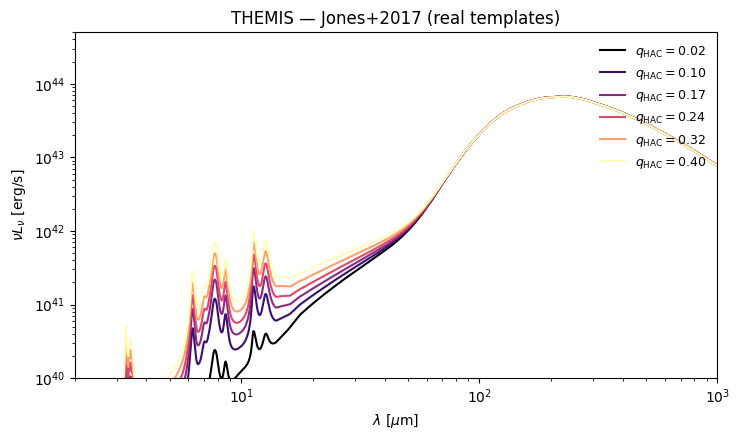

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$ [$\mu$m]"); ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_xlim(2, 1e3); ax.set_ylim(1e40, 5e44)

cmap = plt.get_cmap("magma")
for k, qhac in enumerate([0.02, 0.10, 0.17, 0.24, 0.32, 0.40]):
    L_nu = DUST_EMISSION_MODELS["themis"](
        wave_aa, L_absorbed=L_ABS, dust_umin=1.0,
        dust_gamma_dl=0.01, dust_qhac=qhac,
    )
    ax.plot(wave_um, nu * np.asarray(L_nu), color=cmap(k / 5), lw=1.5,
            label=fr"$q_{{\rm HAC}}={qhac:.2f}$")
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.set_title("THEMIS — Jones+2017 (real templates)")

fig.tight_layout()
plt.show()

## Summary

* All 11 dust emission models in ``DUST_EMISSION_MODELS`` enforce
  energy balance: $\int L_\nu \, d\nu = L_{\rm absorbed}$.
* The four template grids that previously shipped synthetic stand-in
  data — `astrodust`, `bosa`, `themis`, plus the new `draine2021_pah`
  — are now backed by canonical published datasets fetched at build
  time.
* See the `examples/dust/` sphinx-gallery for parameter sweeps across
  the full published range of each model.

For the new SEDComponent-Protocol dispatch (which carries the
PAHspec template and supports ``pahspec_starlight="auto"``
nearest-neighbour selection from upstream stellar parameters), see
`examples/astrodust_hd23/` for the full reproduction of the H&D 2023
``model_file_tutorial.ipynb`` figures.